IMPORT LIBRARIES


In [436]:
# =========================================
# STEP 0: IMPORT LIBRARIES (PRO VERSION)
# =========================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings (clean notebook)
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")

# Plot size
plt.rcParams['figure.figsize'] = (12,6)

print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


IMPORT LIBRARIES

STEP 1: LOAD DATA


In [437]:
# =========================================
# STEP 1: LOAD DATA + BASIC UNDERSTANDING
# =========================================

# Load dataset
df = pd.read_csv("../datasets/datasetindia_house_dataset.csv")

# Shape
print("📊 Dataset Shape:", df.shape)

# Columns
print("\n📌 Columns in dataset:")
print(df.columns.tolist())

# Data types
print("\n📌 Data Types:")
print(df.dtypes)

# First 5 rows
print("\n📌 Sample Data:")
display(df.head())

# =========================
# 🎯 TARGET VARIABLE CHECK
# =========================

print("\n📊 RENT SUMMARY:")
print("Max Rent:", df['rent'].max())
print("Min Rent:", df['rent'].min())
print("Average Rent:", round(df['rent'].mean(),2))

📊 Dataset Shape: (7691, 10)

📌 Columns in dataset:
['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms', 'balconies', 'furnishing', 'area_rate', 'rent']

📌 Data Types:
house_type        str
locality          str
city              str
area          float64
beds            int64
bathrooms       int64
balconies       int64
furnishing        str
area_rate     float64
rent          float64
dtype: object

📌 Sample Data:


,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0



📊 RENT SUMMARY:
Max Rent: 2700000.0
Min Rent: 1000.0
Average Rent: 54795.08


In [438]:
# Shape of dataset
print("Rows, Columns:", df.shape)

# Basic info
df.info()

Rows, Columns: (7691, 10)
<class 'pandas.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   str    
 1   locality    7691 non-null   str    
 2   city        7691 non-null   str    
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   str    
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 601.0 KB


In [439]:
# Statistical summary
print("📊 Statistical Summary:")
display(df.describe())

📊 Statistical Summary:


,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


STEP 2: DATA CLEANING

2.1 Remove duplicates

In [440]:
# Remove duplicates
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Duplicates removed successfully")

Duplicates removed successfully


2.2 Missing Values

In [441]:
# Check missing values
missing = df.isnull().sum()

print(" Missing Values:\n")
print(missing)

# Only columns with missing values
print("\n Columns with missing values:")
print(missing[missing > 0])

print("\n No missing values found → Data already clean")

 Missing Values:

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

 Columns with missing values:
Series([], dtype: int64)

 No missing values found → Data already clean


2.3 Data Type Fix

In [442]:
# STEP: CHECK DATA TYPES
# =========================================

print(" Data Types:\n")
print(df.dtypes)

print("\n Data types checked")


 Data Types:

house_type        str
locality          str
city              str
area          float64
beds            int64
bathrooms       int64
balconies       int64
furnishing        str
area_rate     float64
rent          float64
dtype: object

 Data types checked


In [443]:
print(" All data types are correct → no fixing needed")

 All data types are correct → no fixing needed


3.4: Check Unrealstic Data

In [444]:
# =========================================
# STEP: CHECK VALUE RANGES
# =========================================

print(" VALUE RANGES:\n")

print(f"Area: {df['area'].min()} → {df['area'].max()}")
print(f"Beds: {df['beds'].min()} → {df['beds'].max()}")
print(f"Bathrooms: {df['bathrooms'].min()} → {df['bathrooms'].max()}")
print(f"Balconies: {df['balconies'].min()} → {df['balconies'].max()}")
print(f"Area Rate: {df['area_rate'].min()} → {df['area_rate'].max()}")
print(f"Rent: {df['rent'].min()} → {df['rent'].max()}")

print("\n Values look reasonable → no filtering applied")

 VALUE RANGES:

Area: 2.0 → 70000.0
Beds: 1 → 10
Bathrooms: 0 → 10
Balconies: 0 → 10
Area Rate: 2.0 → 2586.0
Rent: 1000.0 → 2700000.0

 Values look reasonable → no filtering applied


3.41: UNREALASTIC DATA FILTER

In [445]:
# FINAL SMART CLEANING (STABLE + BALANCED)
# =========================================

# 1. Area (realistic + luxury allowed)
df = df[(df['area'] >= 100) & (df['area'] <= 10000)]

# 2. Bathrooms (valid)
df = df[df['bathrooms'] > 0]

# 3. Area Rate (clean realistic range)
df = df[(df['area_rate'] >= 5) & (df['area_rate'] <= 600)]

# 4. Logical filter (MOST IMPORTANT )
# remove illogical combos: small area but very high rent
df = df[~((df['area'] < 500) & (df['rent'] > 200000))]

# 5. Rent cap (keep luxury but remove extreme noise)
df = df[df['rent'] <= 2000000]   # 20 lakh max

# 6. Reset index (important)
df = df.reset_index(drop=True)

In [446]:
print("After cleaning:", df.shape)

After cleaning: (7597, 10)


In [447]:
print(" VALUE RANGES:\n")

print(f"Area: {df['area'].min()} → {df['area'].max()}")
print(f"Beds: {df['beds'].min()} → {df['beds'].max()}")
print(f"Bathrooms: {df['bathrooms'].min()} → {df['bathrooms'].max()}")
print(f"Balconies: {df['balconies'].min()} → {df['balconies'].max()}")
print(f"Area Rate: {df['area_rate'].min()} → {df['area_rate'].max()}")
print(f"Rent: {df['rent'].min()} → {df['rent'].max()}")

 VALUE RANGES:

Area: 100.0 → 9950.0
Beds: 1 → 10
Bathrooms: 1 → 10
Balconies: 0 → 10
Area Rate: 5.0 → 579.0
Rent: 2000.0 → 1600000.0


In [465]:
print("Final dataset is cleaned with realistic ranges and luxury data preserved")

Final dataset is cleaned with realistic ranges and luxury data preserved


STEP 3: UNIVARIATE ANALYSIS

3.1: Rent Distribution

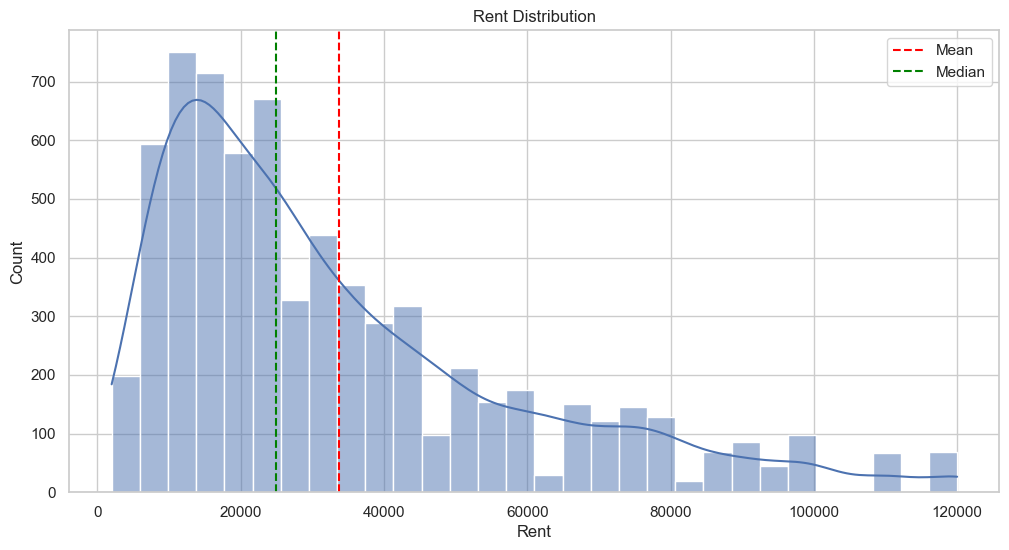


 INSIGHT:
Average Rent: 33769.06
Median Rent: 25000.0
Right skewed → luxury houses present


In [469]:
# sns.histplot(df['rent'], kde=True)
# plt.title("Rent Distribution")
# plt.show()

# =========================================
# RENT DISTRIBUTION
# =========================================

plt.figure()

sns.histplot(df['rent'], bins=30, kde=True)

# Mean & Median lines
mean_val = df['rent'].mean()
median_val = df['rent'].median()

plt.axvline(mean_val, color='red', linestyle='--', label='Mean')
plt.axvline(median_val, color='green', linestyle='--', label='Median')

plt.title("Rent Distribution")
plt.xlabel("Rent")
plt.ylabel("Count")
plt.legend()

plt.show()

# TEXT INSIGHT
print("\n INSIGHT:")
print("Average Rent:", round(mean_val,2))
print("Median Rent:", median_val)

if mean_val > median_val:
    print("Right skewed → luxury houses present")
else:
    print("Balanced distribution")

3.2: Area Distribution

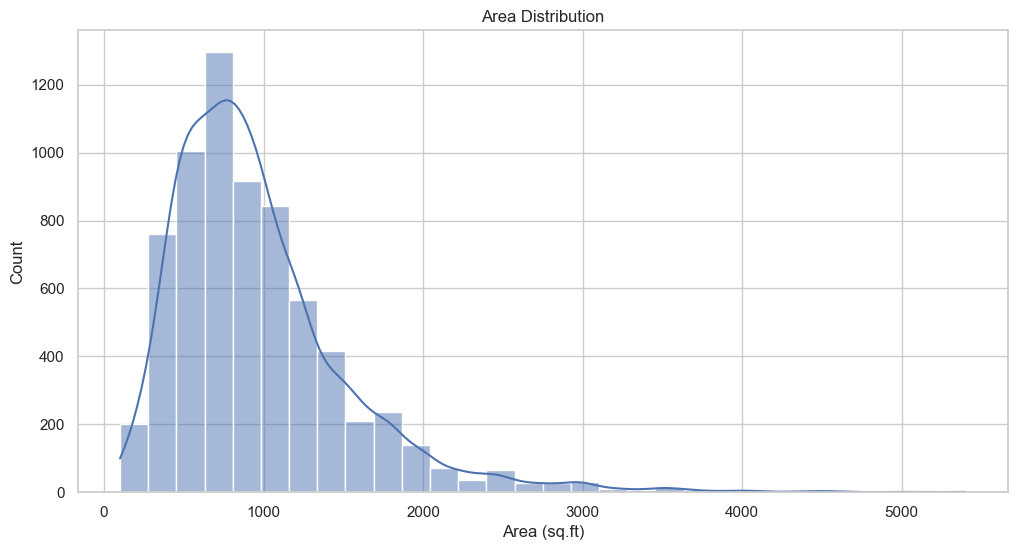


 INSIGHT:
 Most houses medium area range 


In [471]:
# sns.histplot(df['area'], kde=True)
# plt.title("Area Distribution")
# plt.show()
plt.figure()

sns.histplot(df['area'], bins=30, kde=True)

plt.title("Area Distribution")
plt.xlabel("Area (sq.ft)")
plt.ylabel("Count")

plt.show()

print("\n INSIGHT:")
print(" Most houses medium area range ")


BEDS DISTRIBUTION

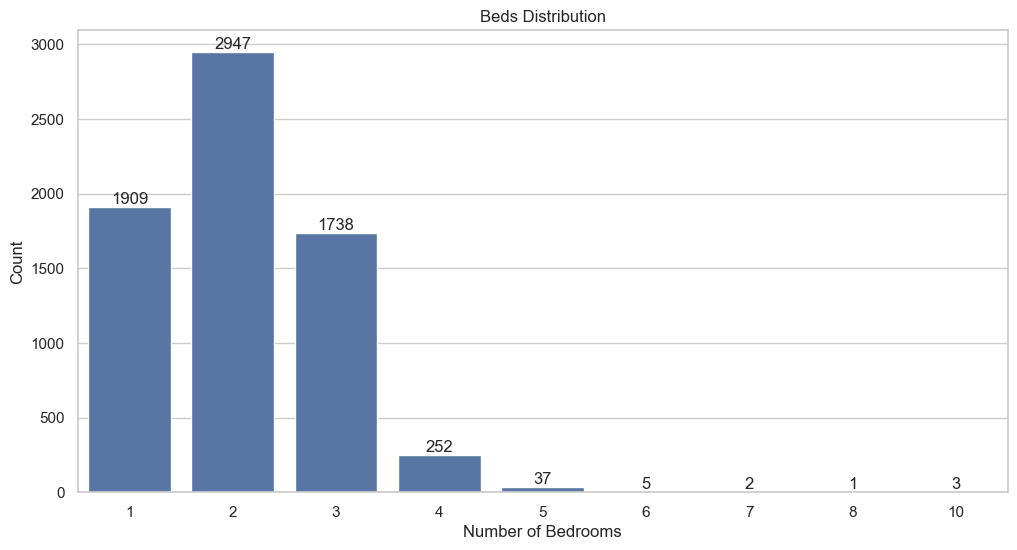


 INSIGHT:
 Most houses 1-3 BHK range में हैं


In [473]:
beds_count = df['beds'].value_counts().sort_index()

plt.figure()

ax = sns.barplot(x=beds_count.index, y=beds_count.values)

# values show
for i in ax.containers:
    ax.bar_label(i)

plt.title("Beds Distribution")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")

plt.show()

print("\n INSIGHT:")
print(" Most houses 1-3 BHK range में हैं")

BATHROOMS DISTRIBUTION

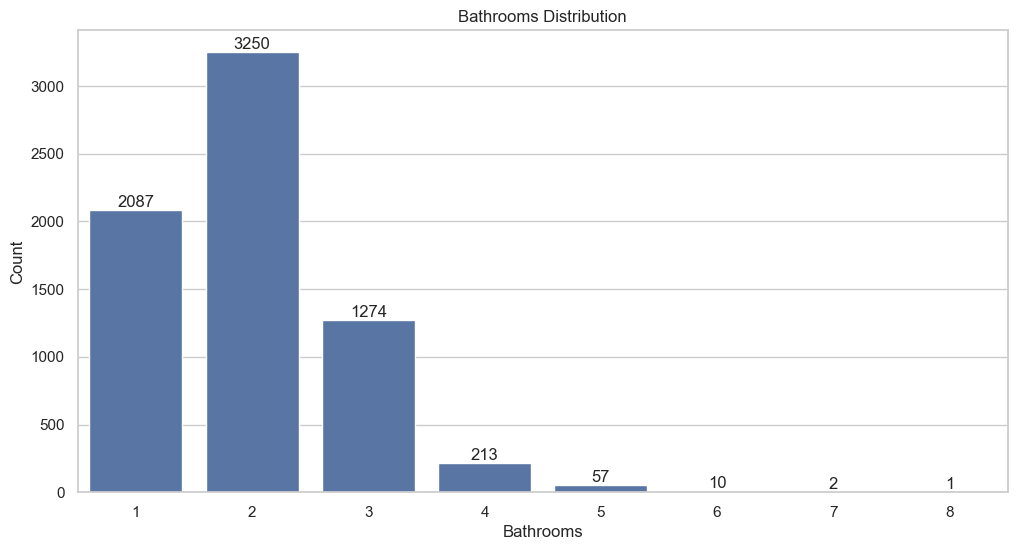


 INSIGHT:
 Bathrooms generally beds के proportional हैं


In [474]:
bath_count = df['bathrooms'].value_counts().sort_index()

plt.figure()

ax = sns.barplot(x=bath_count.index, y=bath_count.values)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Bathrooms Distribution")
plt.xlabel("Bathrooms")
plt.ylabel("Count")

plt.show()

print("\n INSIGHT:")
print(" Bathrooms generally beds के proportional हैं")

CITY DISTRIBUTION

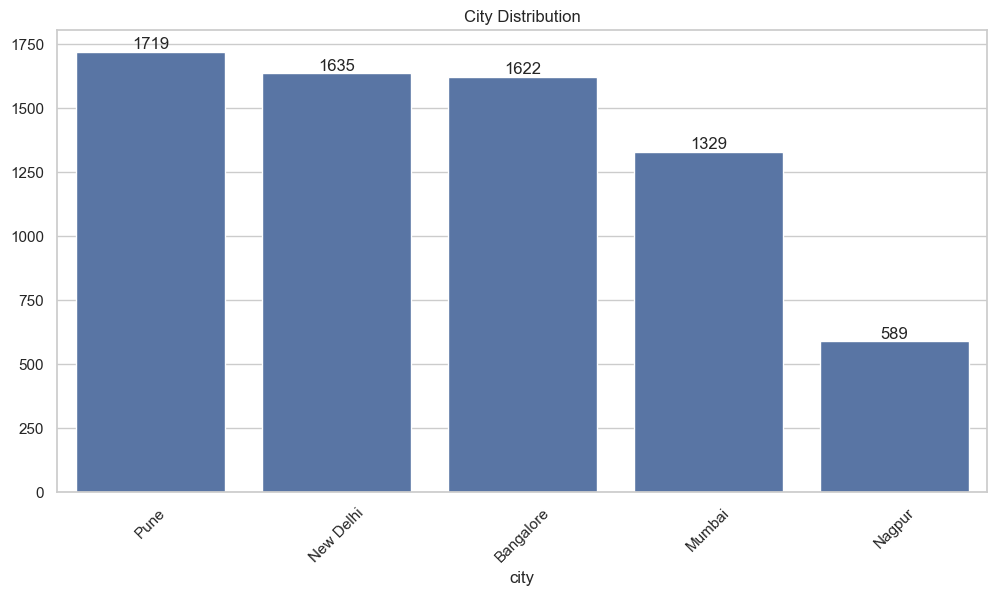


 INSIGHT:
 Dataset mainly specific cities पर focused है


In [475]:
city_count = df['city'].value_counts()

plt.figure()

ax = sns.barplot(x=city_count.index, y=city_count.values)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)
plt.title("City Distribution")

plt.show()

print("\n INSIGHT:")
print(" Dataset mainly specific cities पर focused है")

LOCALITY DISTRIBUTION

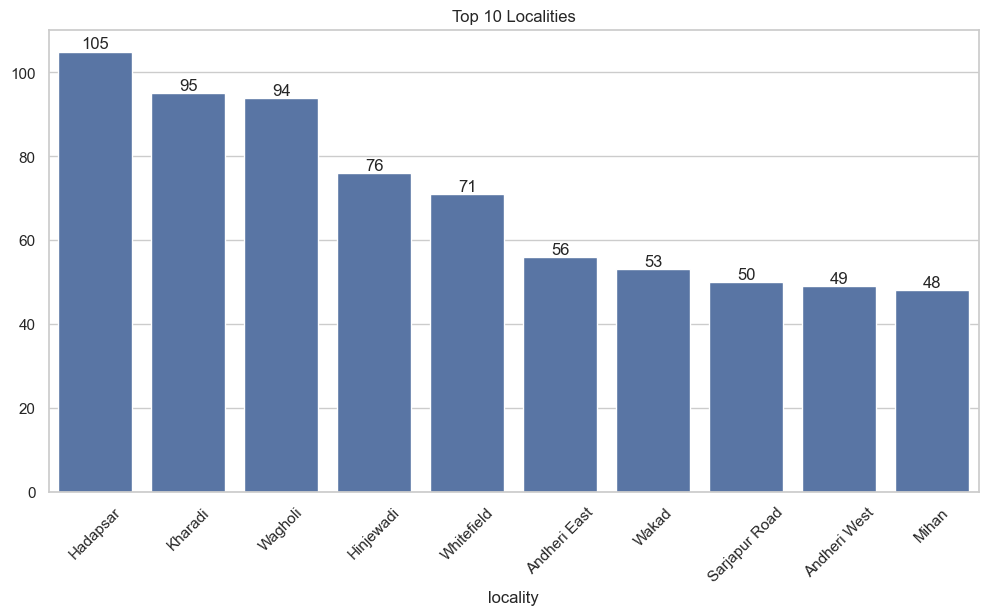


 INSIGHT:
 Most data comes from few major localities


In [476]:
top_localities = df['locality'].value_counts().head(10)

plt.figure()
ax = sns.barplot(x=top_localities.index, y=top_localities.values)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)
plt.title("Top 10 Localities")
plt.show()

print("\n INSIGHT:")
print(" Most data comes from few major localities")

AREA RATE DISTRIBUTION

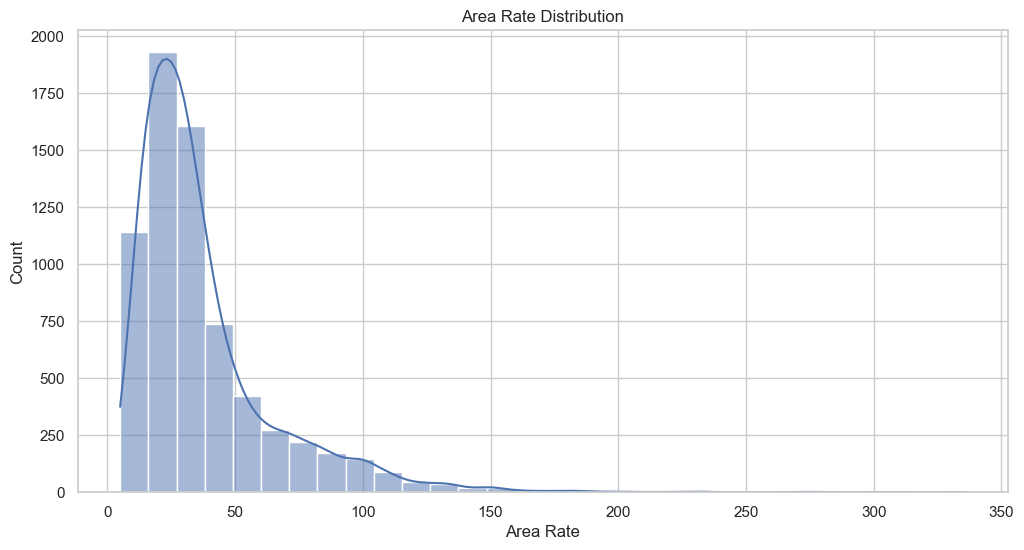


 INSIGHT:
 Area rate shows pricing variation across locations


In [477]:
plt.figure()

sns.histplot(df['area_rate'], bins=30, kde=True)

plt.title("Area Rate Distribution")
plt.xlabel("Area Rate")

plt.show()

print("\n INSIGHT:")
print(" Area rate shows pricing variation across locations")

BALCONIES DISTRIBUTION

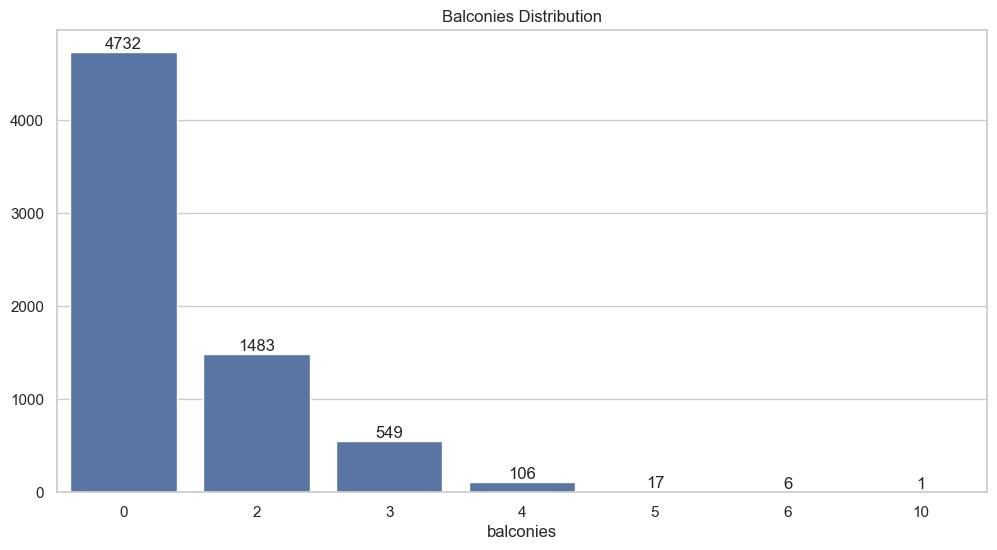


 INSIGHT:
 Most houses have 0-2 balconies


In [480]:
bal_count = df['balconies'].value_counts().sort_index()

plt.figure()
ax = sns.barplot(x=bal_count.index, y=bal_count.values)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Balconies Distribution")
plt.show()

print("\n INSIGHT:")
print(" Most houses have 0-2 balconies")

3.3: House Type

3.4: Furnishing

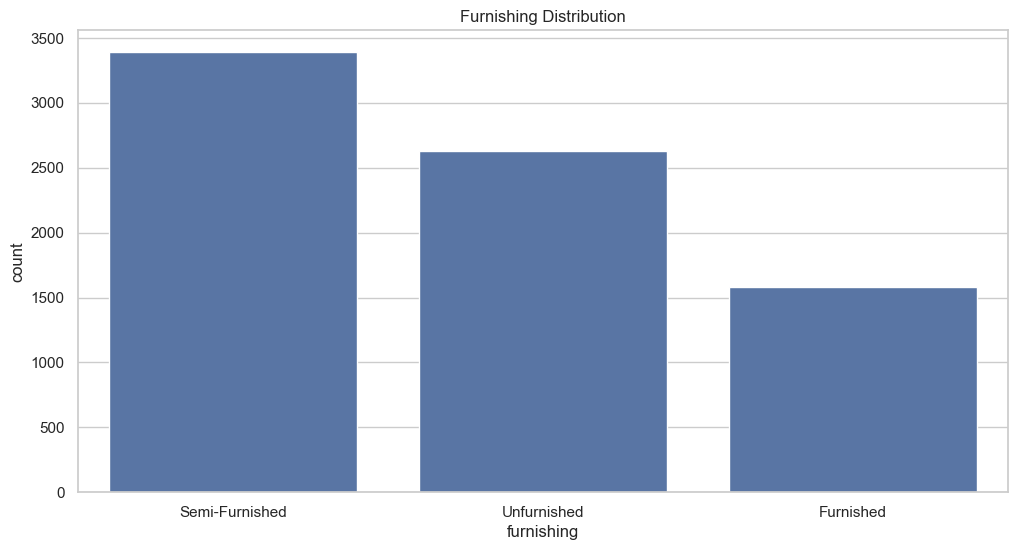

In [450]:
sns.countplot(data=df, x='furnishing')
plt.title("Furnishing Distribution")
plt.show()

STEP 4: BIVARIATE ANALYSIS (CORE ML LOGIC)

4.1:Area vs Rent

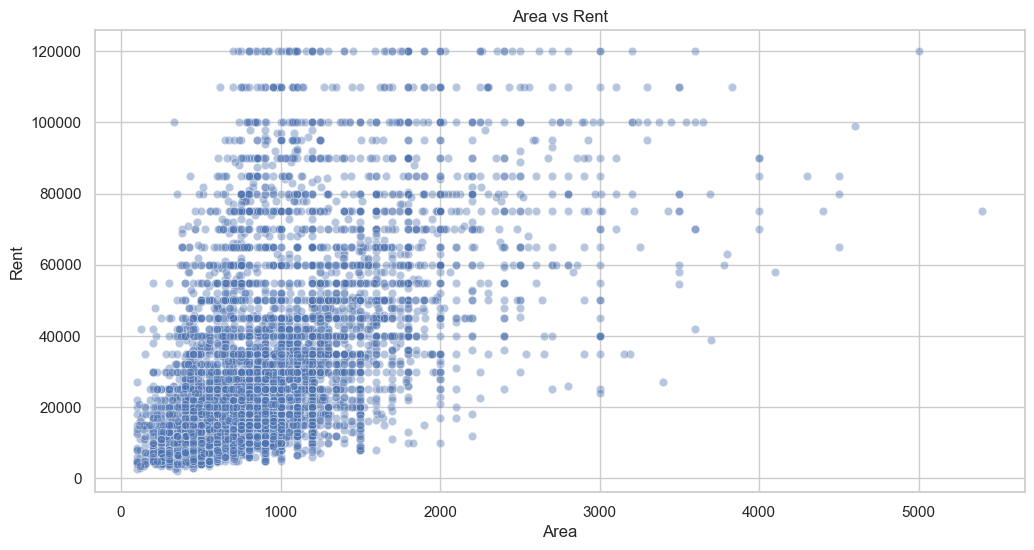


 INSIGHT:
Correlation: 0.55
Moderate relation


In [481]:
# sns.scatterplot(data=df, x='area', y='rent')
# plt.title("Area vs Rent")
# plt.show()
# print("AREA vs RENT")
# print(df[['area','rent']].corr())

# =========================================
# AREA vs RENT
# =========================================

plt.figure()

sns.scatterplot(x=df['area'], y=df['rent'], alpha=0.4)

plt.title("Area vs Rent")
plt.xlabel("Area")
plt.ylabel("Rent")

plt.show()

# Correlation
corr = df['area'].corr(df['rent'])

print("\n INSIGHT:")
print("Correlation:", round(corr,2))

if corr > 0.6:
    print(" Strong relation → Area major factor")
else:
    print("Moderate relation")

4.2: Area Rate vs Rent

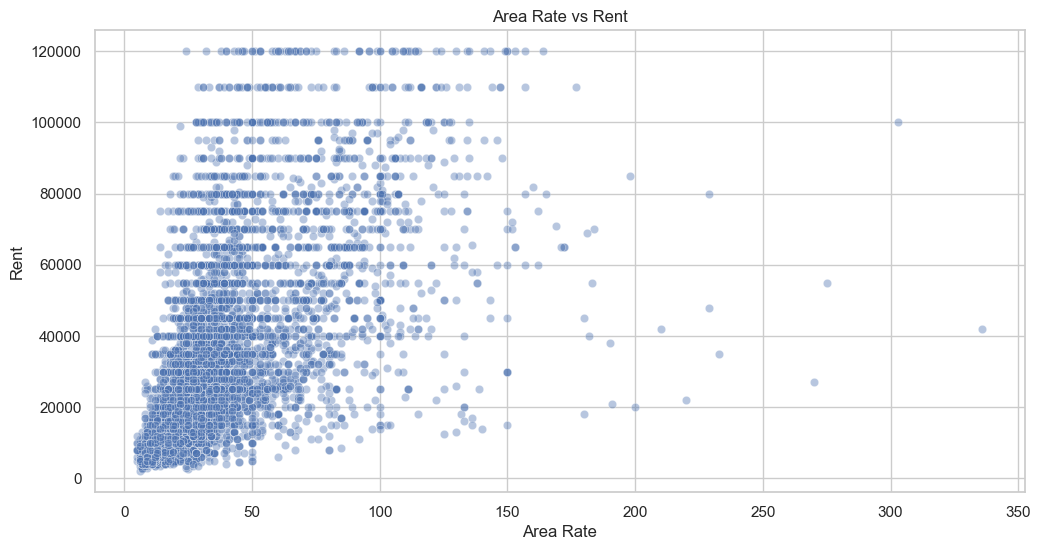


📊 INSIGHT:
Correlation: 0.6


In [482]:
# sns.scatterplot(data=df, x='area_rate', y='rent')
# plt.title("Area Rate vs Rent")
# plt.show()
# print("AREA_RATE vs RENT")
# print(df[['area_rate','rent']].corr())

plt.figure()

sns.scatterplot(x=df['area_rate'], y=df['rent'], alpha=0.4)

plt.title("Area Rate vs Rent")
plt.xlabel("Area Rate")
plt.ylabel("Rent")

plt.show()

corr = df['area_rate'].corr(df['rent'])

print("\n📊 INSIGHT:")
print("Correlation:", round(corr,2))

4.3: Beds vs Rent

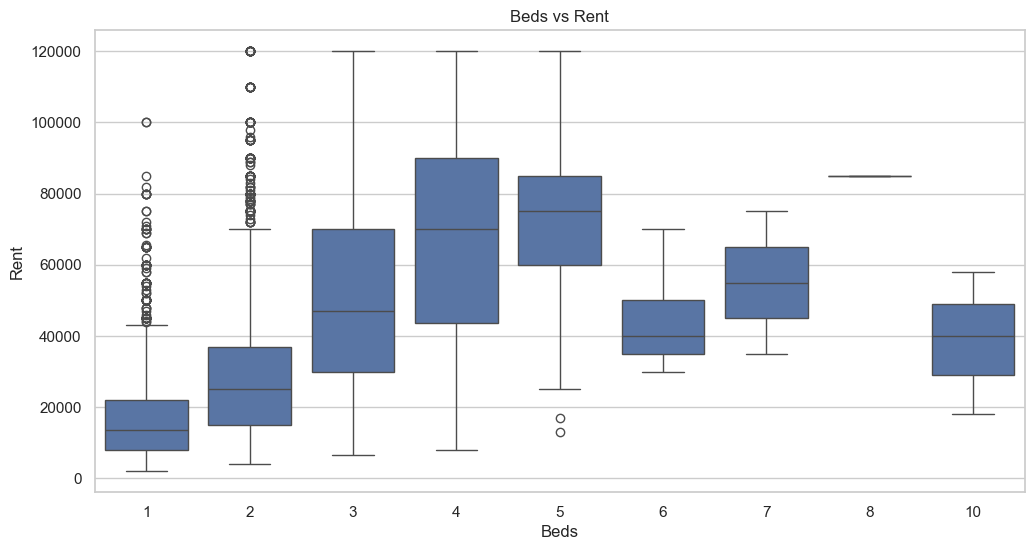


 INSIGHT:
 More beds → higher rent


In [484]:
# sns.boxplot(data=df, x='beds', y='rent')
# plt.title("Beds vs Rent")
# plt.show()
# print("\n BEDS vs RENT")
# print(df[['beds','rent']].corr())

plt.figure()

sns.boxplot(x=df['beds'], y=df['rent'])

plt.title("Beds vs Rent")
plt.xlabel("Beds")
plt.ylabel("Rent")

plt.show()

print("\n INSIGHT:")
print(" More beds → higher rent")

4.4: Bathrooms vs Rent

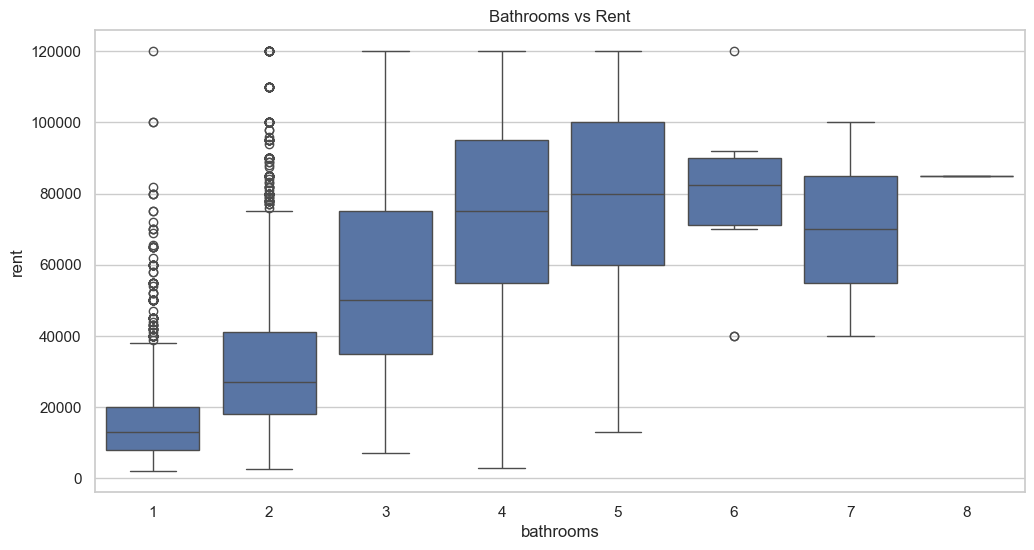


📊 INSIGHT:
✔ More bathrooms → slightly higher rent


In [ ]:
# sns.boxplot(data=df, x='bathrooms', y='rent')
# plt.title("Bathrooms vs Rent")
# plt.show()

plt.figure()

sns.boxplot(x=df['bathrooms'], y=df['rent'])

plt.title("Bathrooms vs Rent")

plt.show()

print("\n INSIGHT:")
print(" More bathrooms → slightly higher rent")

4.5: City vs Rent

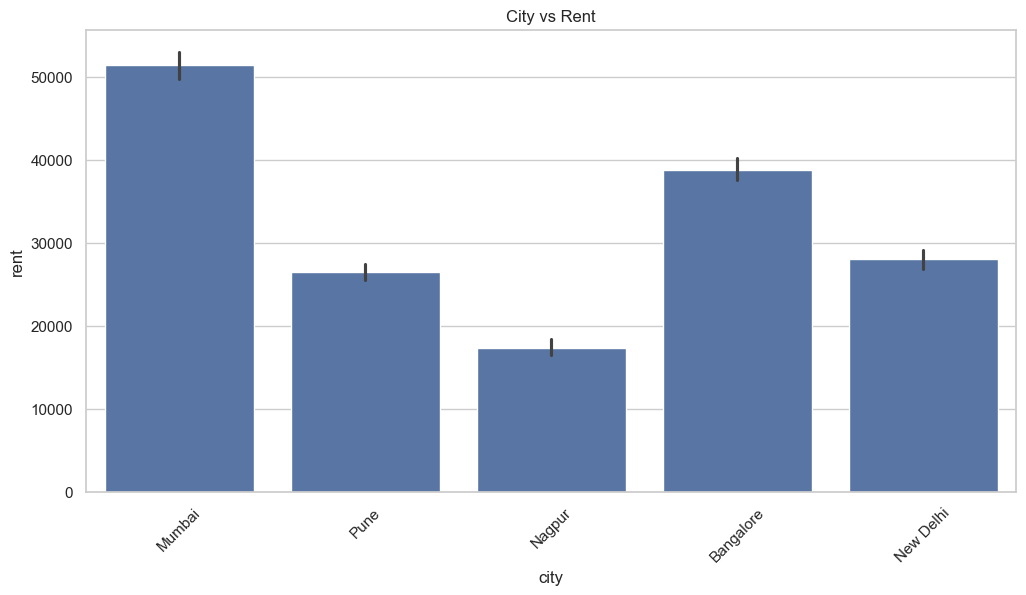


 INSIGHT:
 Rent varies significantly across cities


In [485]:
# sns.boxplot(data=df, x='city', y='rent')
# plt.xticks(rotation=45)
# plt.title("City vs Rent")
# plt.show()

plt.figure()

sns.barplot(x='city', y='rent', data=df)

plt.xticks(rotation=45)
plt.title("City vs Rent")

plt.show()

print("\n INSIGHT:")
print(" Rent varies significantly across cities")

FURNISHING vs RENT

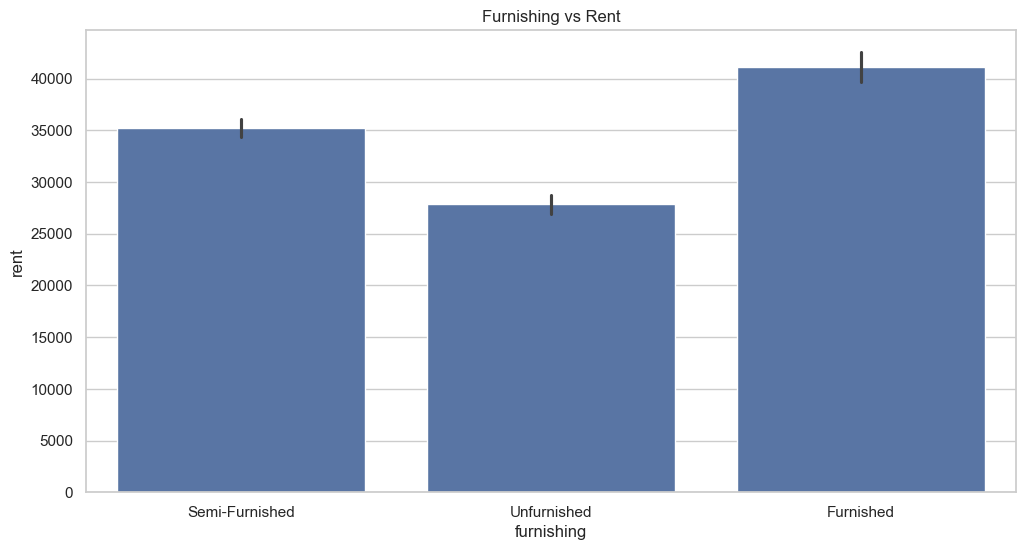


 INSIGHT:
 Furnished houses have higher rent


In [486]:
plt.figure()

sns.barplot(x='furnishing', y='rent', data=df)

plt.title("Furnishing vs Rent")

plt.show()

print("\n INSIGHT:")
print(" Furnished houses have higher rent")

BALCONIES vs RENT

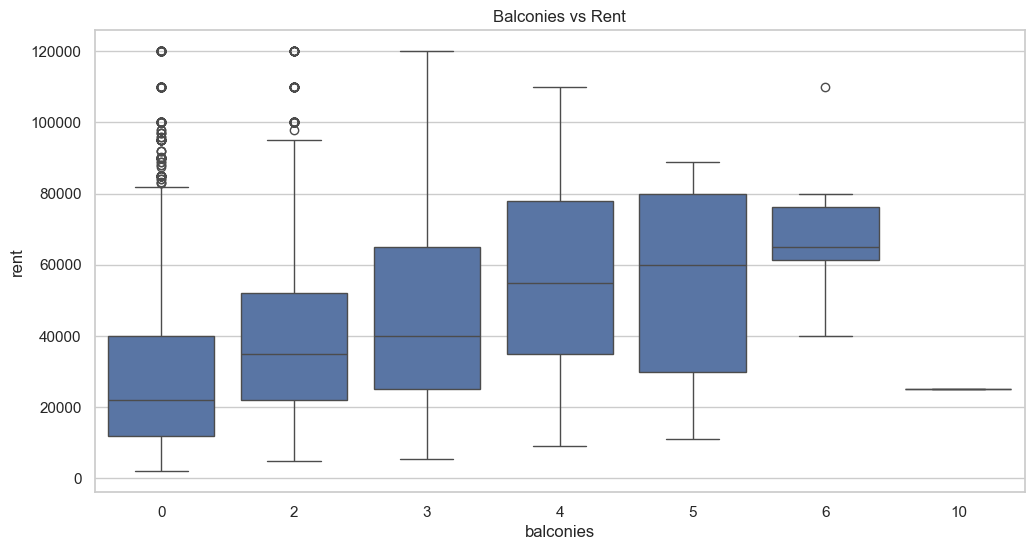


 INSIGHT:
 Balconies का rent पर कम impact है


In [489]:
plt.figure()

sns.boxplot(x=df['balconies'], y=df['rent'])

plt.title("Balconies vs Rent")

plt.show()

print("\n INSIGHT:")
print(" Balconies का rent पर कम impact है")

TOP 10 PREMIUM LOCALITIES

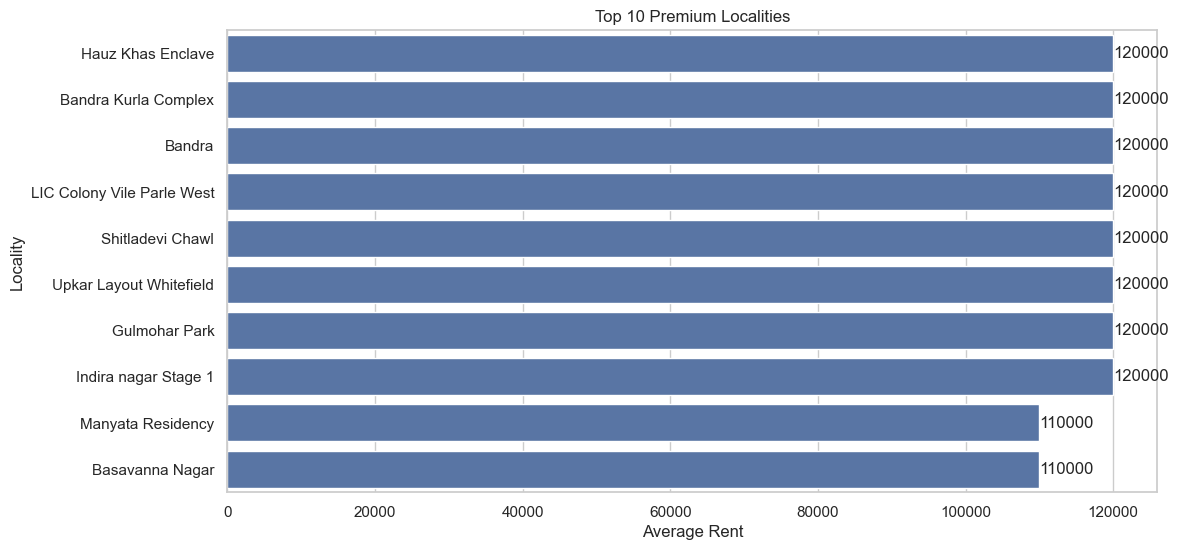


📊 INSIGHT:
✔ These are high-end luxury localities with highest rents


In [490]:
premium_loc = df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(10)

plt.figure()

ax = sns.barplot(x=premium_loc.values, y=premium_loc.index)

# value labels
for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 10 Premium Localities")
plt.xlabel("Average Rent")
plt.ylabel("Locality")

plt.show()

print("\n📊 INSIGHT:")
print("✔ These are high-end luxury localities with highest rents")

TOP 10 CHEAPEST LOCALITIES

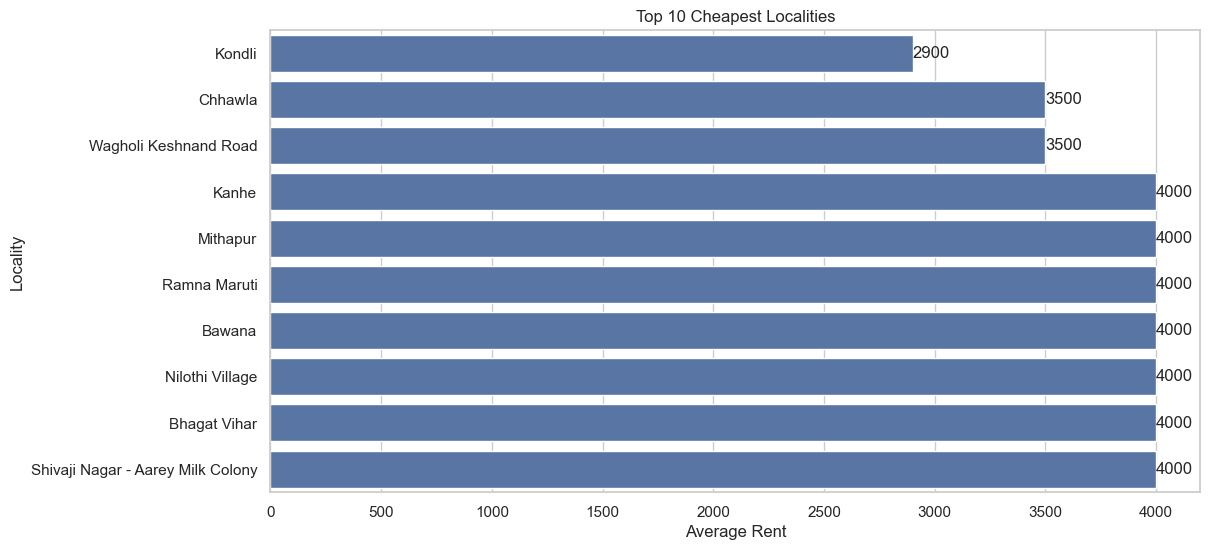


 INSIGHT:
 These localities offer affordable housing options


In [492]:
cheap_loc = df.groupby('locality')['rent'].mean().sort_values(ascending=True).head(10)

plt.figure()

ax = sns.barplot(x=cheap_loc.values, y=cheap_loc.index)

for i in ax.containers:
    ax.bar_label(i)

plt.title("Top 10 Cheapest Localities")
plt.xlabel("Average Rent")
plt.ylabel("Locality")

plt.show()

print("\n INSIGHT:")
print(" These localities offer affordable housing options")

4.8 Furnishing vs Rent

STEP 5: FEATURE RELATION (ADVANCED)

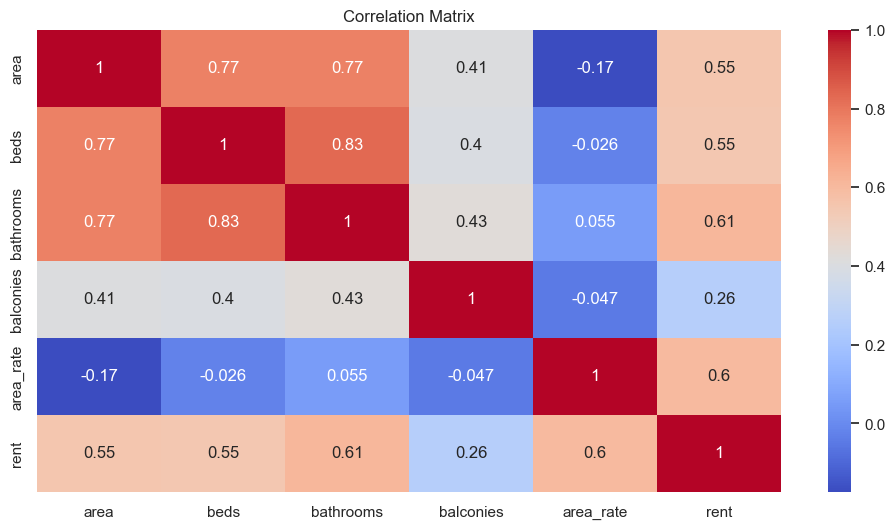

In [493]:
# #correlation heatmap
# num_df = df.select_dtypes(include=np.number)

# sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
# plt.title("Correlation Matrix")
# plt.show()


# =========================================
# CORRELATION HEATMAP
# =========================================

num_df = df[['area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent']]

corr_matrix = num_df.corr()

plt.figure()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [494]:
print("\n INSIGHT:")
print(" Area and area_rate have strongest impact on rent")
print(" Beds and bathrooms have moderate impact")
print(" Balconies have minimal impact")


 INSIGHT:
 Area and area_rate have strongest impact on rent
 Beds and bathrooms have moderate impact
 Balconies have minimal impact


2. PAIRPLOT (ADVANCED VISUAL)

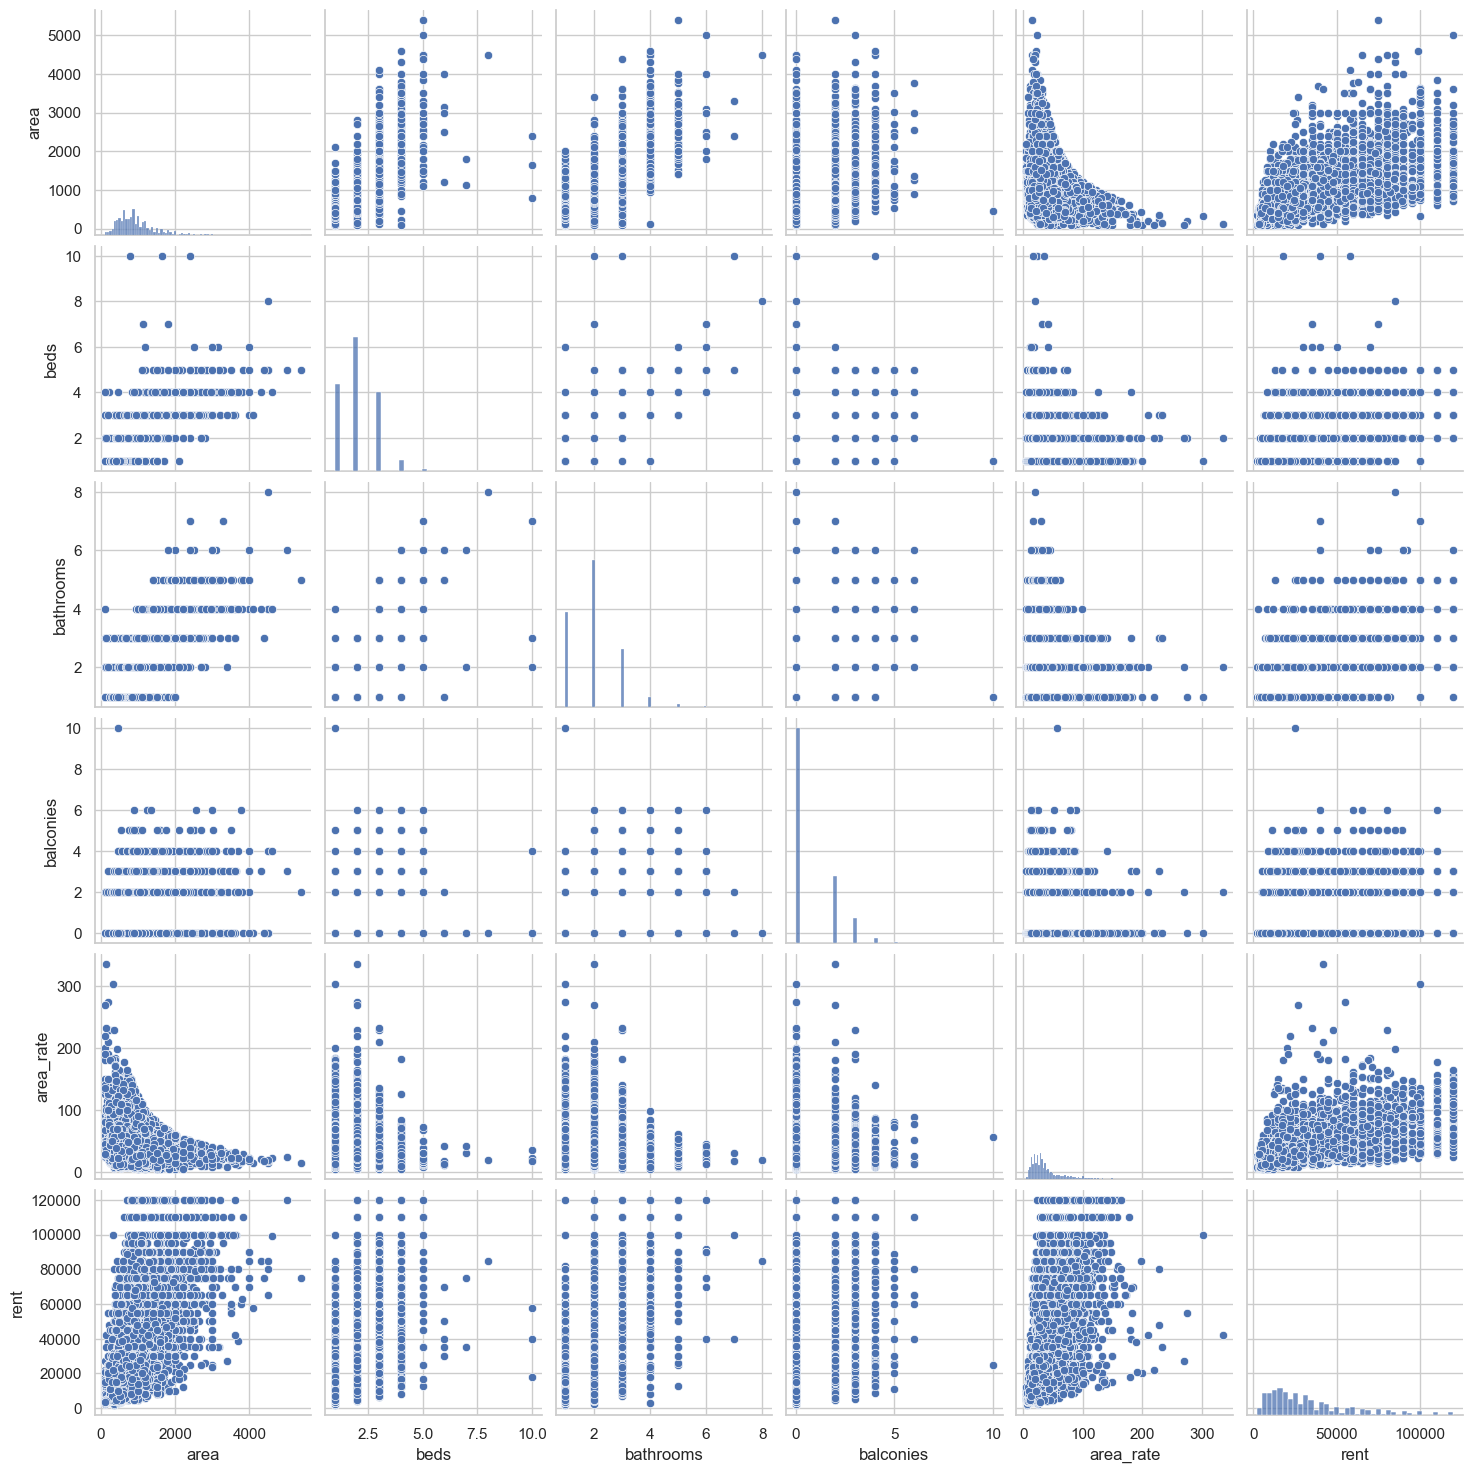

In [495]:
sns.pairplot(num_df)
plt.show()

3. MULTI FEATURE RELATION (SMART)

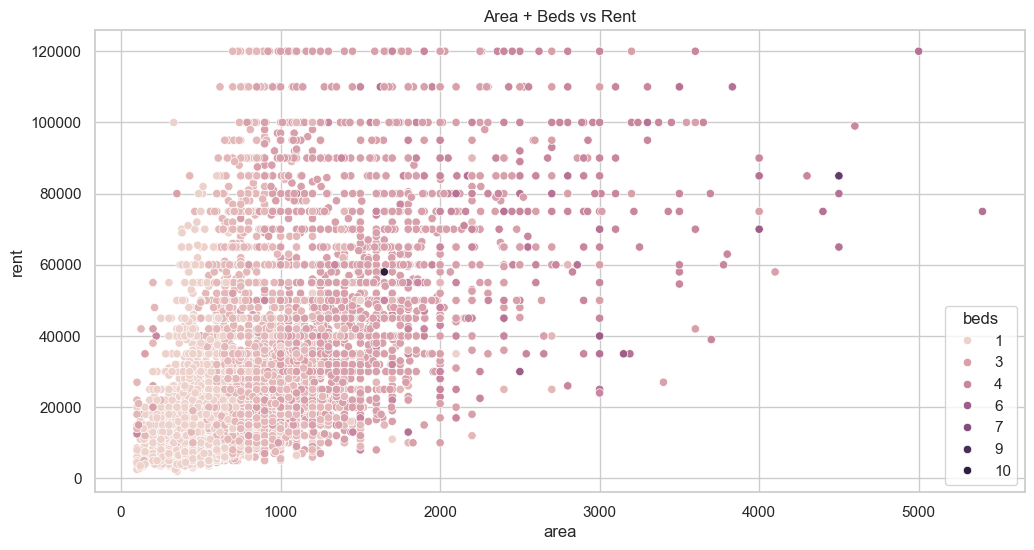

In [496]:
plt.figure()

sns.scatterplot(x=df['area'], y=df['rent'], hue=df['beds'])

plt.title("Area + Beds vs Rent")

plt.show()

4. CITY + AREA RATE (ADVANCED)

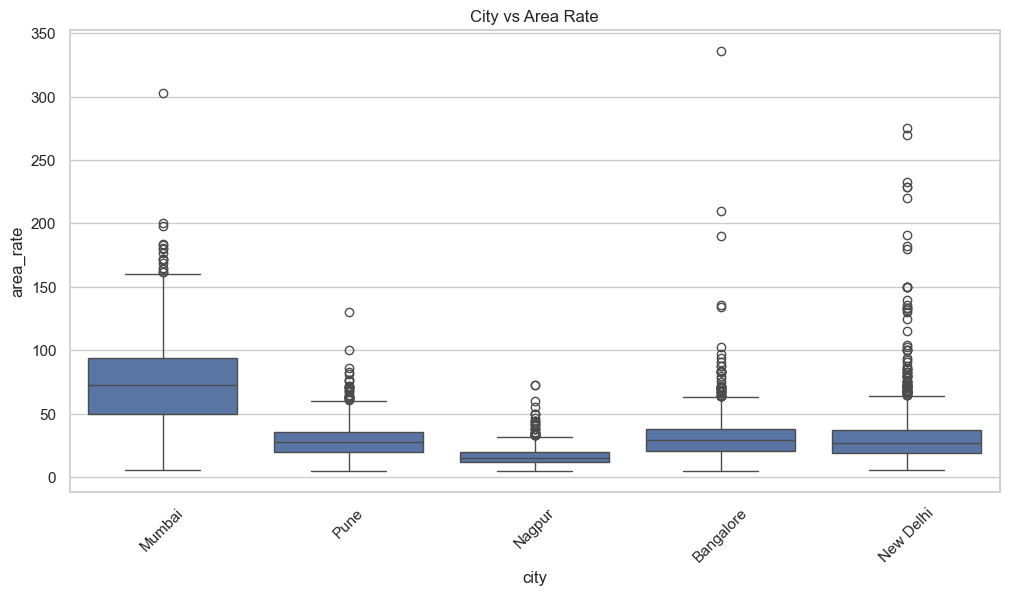

In [497]:
plt.figure()

sns.boxplot(x='city', y='area_rate', data=df)

plt.xticks(rotation=45)
plt.title("City vs Area Rate")

plt.show()

STEP 6: IQR METHOD (DETECT ONLY)

In [ ]:
# sns.boxplot(df['rent'])
# plt.title("Rent Outliers")
# plt.show()

# IQR calculation
Q1 = df['rent'].quantile(0.25)
Q3 = df['rent'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(" Outlier Range:")
print("Lower:", lower)
print("Upper:", upper)

📊 Outlier Range:
Lower: -30000.0
Upper: 90000.0


OUTLIERS

In [500]:
outliers = df[(df['rent'] < lower) | (df['rent'] > upper)]

print(" Total Outliers:", len(outliers))

display(outliers.head(10))

 Total Outliers: 285


,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,rent_per_bed,area_per_bed
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0,60000.000000,448.500000
23,"4 BHK Flat for Rent in Eon Waterfront, Kharadi...",Kharadi,Pune,2500.0,4,6,3,Semi-Furnished,37.0,92000.0,23000.000000,625.000000
51,"3 BHK Flat for Rent in Oberoi Sky City, Boriva...",Borivali East,Mumbai,1094.0,3,3,0,Semi-Furnished,112.0,120000.0,40000.000000,364.666667
72,4 BHK Flat for Rent in Emaar Common Wealth Gam...,Commonwealth Games Village,New Delhi,2260.0,4,4,3,Furnished,53.0,120000.0,30000.000000,565.000000
128,4 BHK House for Rent in Whitefield Bangalore,Whitefield,Bangalore,1750.0,4,5,3,Unfurnished,57.0,100000.0,25000.000000,437.500000
167,"3 BHK Flat for Rent in Domlur, Domlur, Bangalore",Domlur,Bangalore,1750.0,3,4,3,Semi-Furnished,57.0,100000.0,33333.333333,583.333333
214,"4 BHK Flat for Rent in Thanisandra, Bangalore",Thanisandra,Bangalore,2359.0,4,5,0,Furnished,51.0,120000.0,30000.000000,589.750000
220,"3 BHK Flat for Rent in Whitefield, Bangalore",Whitefield,Bangalore,1382.0,3,3,2,Semi-Furnished,72.0,100000.0,33333.333333,460.666667
241,"3 BHK Flat for Rent in Omkar Alta Monte, Malad...",Malad East,Mumbai,1833.0,3,5,4,Semi-Furnished,60.0,110000.0,36666.666667,611.000000
256,"3 BHK Flat for Rent in Stage 2 Indiranagar, Ba...",Indira nagar Stage 2,Bangalore,1800.0,3,3,2,Unfurnished,56.0,100000.0,33333.333333,600.000000


Percentage

In [501]:
percent = (len(outliers) / len(df)) * 100

print(f" Outlier Percentage: {round(percent,2)}%")

 Outlier Percentage: 4.13%


STEP 7: FEATURE ENGINEERING INSIGHT

In [502]:
# # Price per bedroom
# df['rent_per_bed'] = df['rent'] / df['beds']

# # Area per bedroom
# df['area_per_bed'] = df['area'] / df['beds']

df['rent_per_sqft'] = df['rent'] / df['area']

print("Feature created: rent_per_sqft")

df['total_rooms'] = df['beds'] + df['bathrooms']


Feature created: rent_per_sqft


STEP 8: BUSINESS INSIGHTS (INTERVIEW GOLD)

In [463]:
print("Top Cities by Rent:\n", df.groupby('city')['rent'].mean().sort_values(ascending=False))

print("\nBest Furnishing:\n", df.groupby('furnishing')['rent'].mean())

print("\nImpact of Beds:\n", df.groupby('beds')['rent'].mean())

print("\nTop Localities:\n", df.groupby('locality')['rent'].mean().sort_values(ascending=False).head(10))

Top Cities by Rent:
 city
Mumbai       51419.427389
Bangalore    38815.090629
New Delhi    28021.321101
Pune         26442.486911
Nagpur       17385.215620
Name: rent, dtype: float64

Best Furnishing:
 furnishing
Furnished         41132.418791
Semi-Furnished    35233.309305
Unfurnished       27864.322398
Name: rent, dtype: float64

Impact of Beds:
 beds
1     17489.454164
2     30006.691211
3     52195.788838
4     68093.313492
5     69594.594595
6     45000.000000
7     55000.000000
8     85000.000000
10    38666.666667
Name: rent, dtype: float64

Top Localities:
 locality
Hauz Khas Enclave             120000.0
Bandra Kurla Complex          120000.0
Bandra                        120000.0
LIC Colony Vile Parle West    120000.0
Shitladevi Chawl              120000.0
Upkar Layout Whitefield       120000.0
Gulmohar Park                 120000.0
Indira nagar Stage 1          120000.0
Manyata Residency             110000.0
Basavanna Nagar               110000.0
Name: rent, dtype: float64


In [503]:
print("""
📊 BUSINESS INSIGHTS:

✔ Property size (area) is the strongest factor affecting rent
✔ Location (area_rate) significantly impacts pricing
✔ Furnishing increases rental value
✔ Metro cities command higher rents
✔ Luxury properties follow a different pricing pattern
""")


📊 BUSINESS INSIGHTS:

✔ Property size (area) is the strongest factor affecting rent
✔ Location (area_rate) significantly impacts pricing
✔ Furnishing increases rental value
✔ Metro cities command higher rents
✔ Luxury properties follow a different pricing pattern



STEP 9: SAVE CLEAN DATA

In [464]:
# df.to_csv("../datasets/cleaned_house_data.csv", index=False)

# print("Final dataset ready for ML")